# Sentiment Temporal Analysis:
Goal: Observe how sentiment or topics have changed over time (could indicate improvements or issues in hotels).

A última execução deste notebook inclui os registos aos quais não tirei os acentos nem os espaços múltiplos/parágrafos. Apenas fiz o strip (aka o compress do SAS). Isto melhorou os scores e reduziu os outliers. Removi o "particular".

In [1]:
#!pip install tensorflow
#!pip install tf-keras==2.16.0

In [3]:
import pandas as pd
from transformers import pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
import re
import numpy as np
from collections import Counter
import nltk
import nltk.corpus
import nltk.sentiment
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
#nltk.download('omw-1.4')
#nltk.download('stopwords')
#nltk.download('wordnet')
#nltk.download('punkt')
#nltk.download('averaged_perceptron_tagger')
#nltk.download('maxent_ne_chunker')
#nltk.download('words')
#nltk.download('punkt_tab')
import os
import re
import string
from string import punctuation
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

In [4]:
df = pd.read_csv("reviews_clean_csv_portinari.csv")

In [5]:
df.head(10)

,country,room_type,traveler_type,nr_nights,year,month,score,full_review
0,Germany,Single Room,Solo traveller,3,2024,November,10.0,The best Hotel in this Area.... The best and c...
1,Portugal,Double Room,Couple,1,2024,November,6.0,"Good Breakfast location okay, bath tub not all..."
2,Ireland,Twin Room,Solo traveller,3,2024,September,7.0,Hotel was an ideal base from which to enjoy an...
3,Israel,Single Room,Solo traveller,1,2024,September,7.0,I would come back. Staff was very friendly and...
4,Argentina,Twin Room,Group,4,2024,August,6.0,Good for the price I paid The location was not...
5,Spain,Twin Room,Solo traveller,3,2024,August,7.0,"Everything ok In general terms, all good. The ..."
6,Portugal,Double Room,Couple,1,2024,June,5.0,Passable Front office guy was nice and did his...
7,Czech Republic,Double Room,Family,1,2024,May,5.0,"Passable Nice and helpful staff, good breakfas..."
8,Jordan,Single Room,Solo traveller,10,2023,November,7.0,I would reserve for the 3rd time The staff are...
9,Brazil,Double Room,Couple,1,2023,November,6.0,Pleasant No highlights mentioned. Furnitures a...


In [6]:
print(df['full_review'].tail(10))

1443    Super old all No highlights mentioned. No issu...
1444    Very good No highlights mentioned. No issues m...
1445    Passable No highlights mentioned. No issues me...
1446    Pleasant No highlights mentioned. No issues me...
1447    Good No highlights mentioned. No issues mentio...
1448    Bad No highlights mentioned. No issues mentioned.
1449    Very good No highlights mentioned. No issues m...
1450    Very good No highlights mentioned. No issues m...
1451    Bad No highlights mentioned. No issues mentioned.
1452    Superb No highlights mentioned. No issues ment...
Name: full_review, dtype: object


## Pre Processing

In [8]:
# Mapear meses para números
month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

df['month_numeric'] = df['month'].map(month_map)

# Verificar o resultado
print(df[['month', 'month_numeric']].head())

       month  month_numeric
0   November             11
1   November             11
2  September              9
3  September              9
4     August              8


In [9]:
col_keep = [
    'country', 'room_type', 'traveler_type', 'nr_nights', 'year', 'month_numeric', 'score', 'full_review']
df = df[col_keep]
df = df.rename(columns={'month_numeric': 'month'})

In [10]:
df.head(3)

,country,room_type,traveler_type,nr_nights,year,month,score,full_review
0,Germany,Single Room,Solo traveller,3,2024,11,10.0,The best Hotel in this Area.... The best and c...
1,Portugal,Double Room,Couple,1,2024,11,6.0,"Good Breakfast location okay, bath tub not all..."
2,Ireland,Twin Room,Solo traveller,3,2024,9,7.0,Hotel was an ideal base from which to enjoy an...


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1453 non-null   object 
 1   room_type      1453 non-null   object 
 2   traveler_type  1453 non-null   object 
 3   nr_nights      1453 non-null   int64  
 4   year           1453 non-null   int64  
 5   month          1453 non-null   int64  
 6   score          1453 non-null   float64
 7   full_review    1453 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.9+ KB


## Algorithm

In [13]:
# Carregar o modelo para classificação de emoções
#emotion_pipeline = pipeline("text-classification",model="j-hartmann/emotion-english-distilroberta-base",top_k=None)
emotion_pipeline = pipeline("text-classification",model="j-hartmann/emotion-english-roberta-large",top_k=None)
#emotion_pipeline = pipeline("text-classification",model="michellejieli/emotion_text_classifier",top_k=None)

Device set to use mps:0


In [14]:
def get_sentiment(text):
    if not text.strip():
        return None, None
    emotions = emotion_pipeline(text[:512])[0]  # Limita a 512 tokens
    dominant_emotion = max(emotions, key=lambda x: x['score'])
    return dominant_emotion['label'], dominant_emotion['score']

# Aplicar ao DataFrame
df[['emotion', 'emotion_score']] = df['full_review'].apply(lambda x: pd.Series(get_sentiment(x)))

In [15]:
df.head(20)

,country,room_type,traveler_type,nr_nights,year,month,score,full_review,emotion,emotion_score
0,Germany,Single Room,Solo traveller,3,2024,11,10.0,The best Hotel in this Area.... The best and c...,joy,0.604035
1,Portugal,Double Room,Couple,1,2024,11,6.0,"Good Breakfast location okay, bath tub not all...",sadness,0.678425
2,Ireland,Twin Room,Solo traveller,3,2024,9,7.0,Hotel was an ideal base from which to enjoy an...,joy,0.923643
3,Israel,Single Room,Solo traveller,1,2024,9,7.0,I would come back. Staff was very friendly and...,joy,0.705873
4,Argentina,Twin Room,Group,4,2024,8,6.0,Good for the price I paid The location was not...,neutral,0.746313
5,Spain,Twin Room,Solo traveller,3,2024,8,7.0,"Everything ok In general terms, all good. The ...",neutral,0.664060
6,Portugal,Double Room,Couple,1,2024,6,5.0,Passable Front office guy was nice and did his...,joy,0.358407
7,Czech Republic,Double Room,Family,1,2024,5,5.0,"Passable Nice and helpful staff, good breakfas...",disgust,0.718564
8,Jordan,Single Room,Solo traveller,10,2023,11,7.0,I would reserve for the 3rd time The staff are...,joy,0.514639
9,Brazil,Double Room,Couple,1,2023,11,6.0,Pleasant No highlights mentioned. Furnitures a...,sadness,0.951712


In [16]:
# --- Análise Descritiva ---
print("\nEstatísticas descritivas dos scores por emoção:")
df.groupby('emotion')['emotion_score'].describe()


Estatísticas descritivas dos scores por emoção:


,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
anger,9.0,0.540834,0.133173,0.344967,0.404393,0.570372,0.663183,0.667461
disgust,256.0,0.681365,0.192949,0.182476,0.494835,0.696680,0.845824,0.986276
fear,29.0,0.639003,0.177621,0.363430,0.500812,0.602926,0.746270,0.960629
joy,264.0,0.694741,0.138203,0.358407,0.616917,0.616917,0.798019,0.985976
neutral,640.0,0.803138,0.155346,0.288404,0.759334,0.881715,0.897614,0.956773
sadness,244.0,0.625965,0.159559,0.237171,0.565228,0.610394,0.704750,0.972497
surprise,11.0,0.575597,0.214215,0.313061,0.422261,0.580782,0.724696,0.954276


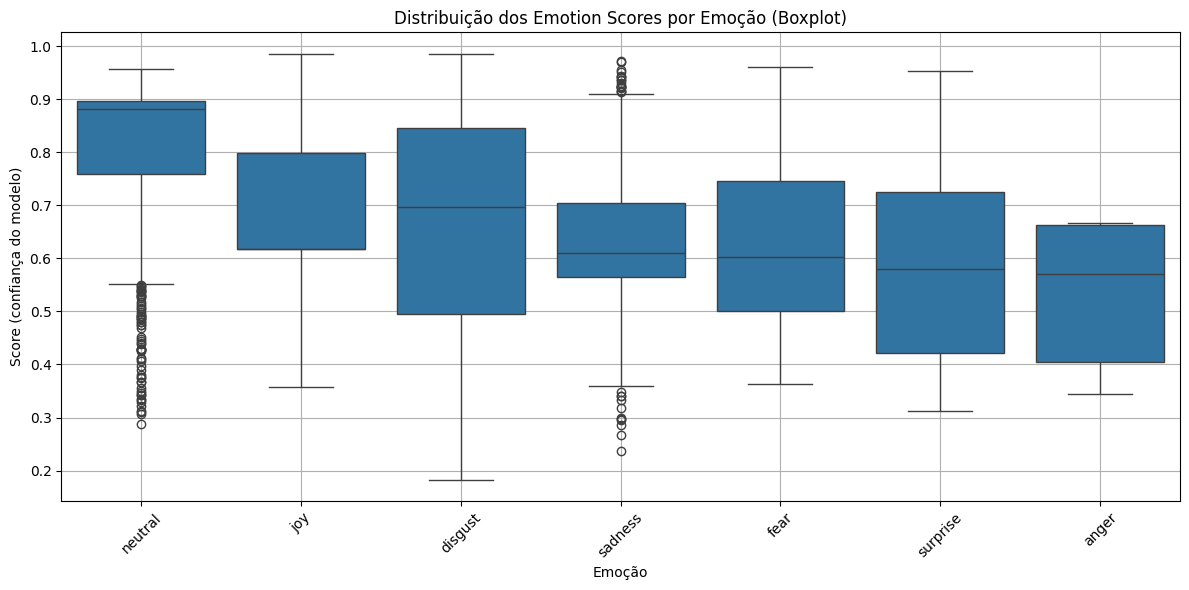

In [17]:
# --- Visualização 1: Boxplot ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='emotion', y='emotion_score', order=df['emotion'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Distribuição dos Emotion Scores por Emoção (Boxplot)")
plt.xlabel("Emoção")
plt.ylabel("Score (confiança do modelo)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1453 non-null   object 
 1   room_type      1453 non-null   object 
 2   traveler_type  1453 non-null   object 
 3   nr_nights      1453 non-null   int64  
 4   year           1453 non-null   int64  
 5   month          1453 non-null   int64  
 6   score          1453 non-null   float64
 7   full_review    1453 non-null   object 
 8   emotion        1453 non-null   object 
 9   emotion_score  1453 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 113.6+ KB


## Analysis of Results

# Temporal Analysis

### Sentiment Evolution Overtime (2022-2025)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1453 entries, 0 to 1452
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        1453 non-null   object 
 1   room_type      1453 non-null   object 
 2   traveler_type  1453 non-null   object 
 3   nr_nights      1453 non-null   int64  
 4   year           1453 non-null   int64  
 5   month          1453 non-null   int64  
 6   score          1453 non-null   float64
 7   full_review    1453 non-null   object 
 8   emotion        1453 non-null   object 
 9   emotion_score  1453 non-null   float64
dtypes: float64(2), int64(3), object(5)
memory usage: 113.6+ KB


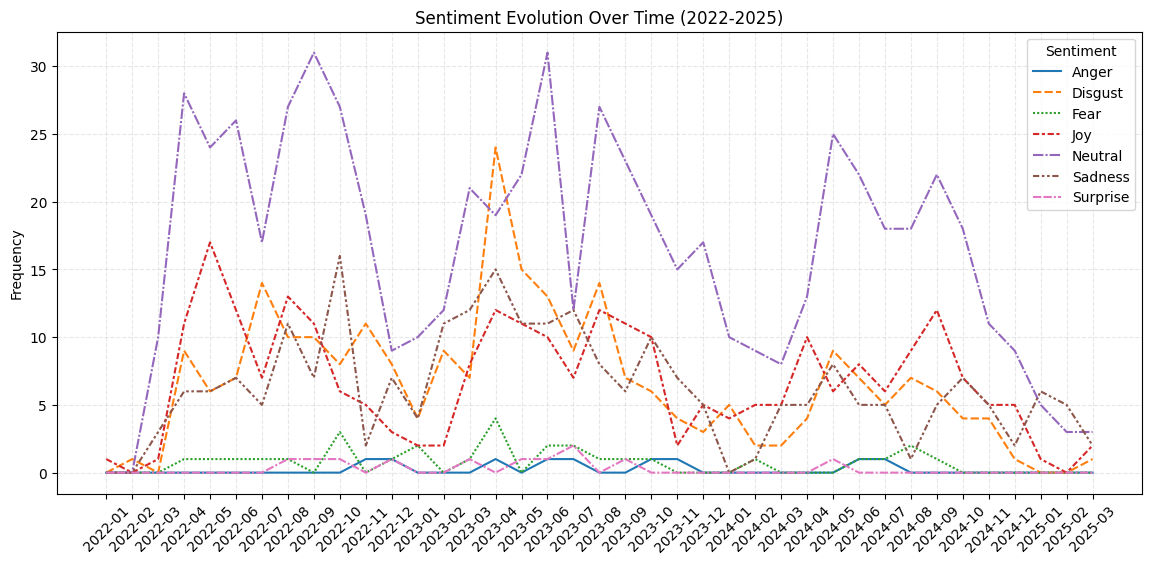

In [23]:
# Criar coluna ano-mês
df["year_month"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)

# Contar ocorrências de emoções por ano-mês
emotion_trend = df.groupby(["year_month", "emotion"]).size().unstack().fillna(0)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=emotion_trend.rename(columns=lambda x: x.capitalize()))
plt.xticks(rotation=45)
plt.title("Sentiment Evolution Over Time (2022-2025)")
plt.xlabel("")
plt.ylabel("Frequency")
plt.legend(title="Sentiment")
plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig("sentiment_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

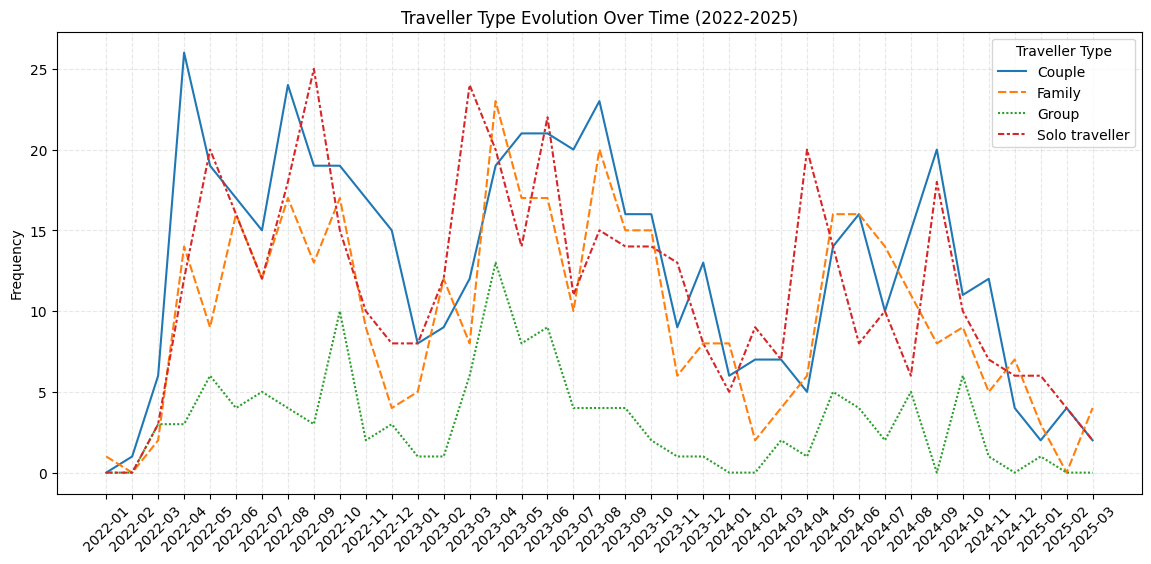

In [24]:
emotion_trend = df.groupby(["year_month", "traveler_type"]).size().unstack().fillna(0)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=emotion_trend)
plt.xticks(rotation=45)
plt.title("Traveller Type Evolution Over Time (2022-2025)")
plt.xlabel("")
plt.ylabel("Frequency")
plt.legend(title="Traveller Type")
plt.grid(True, linestyle="--", alpha=0.3)

plt.savefig("ttype_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

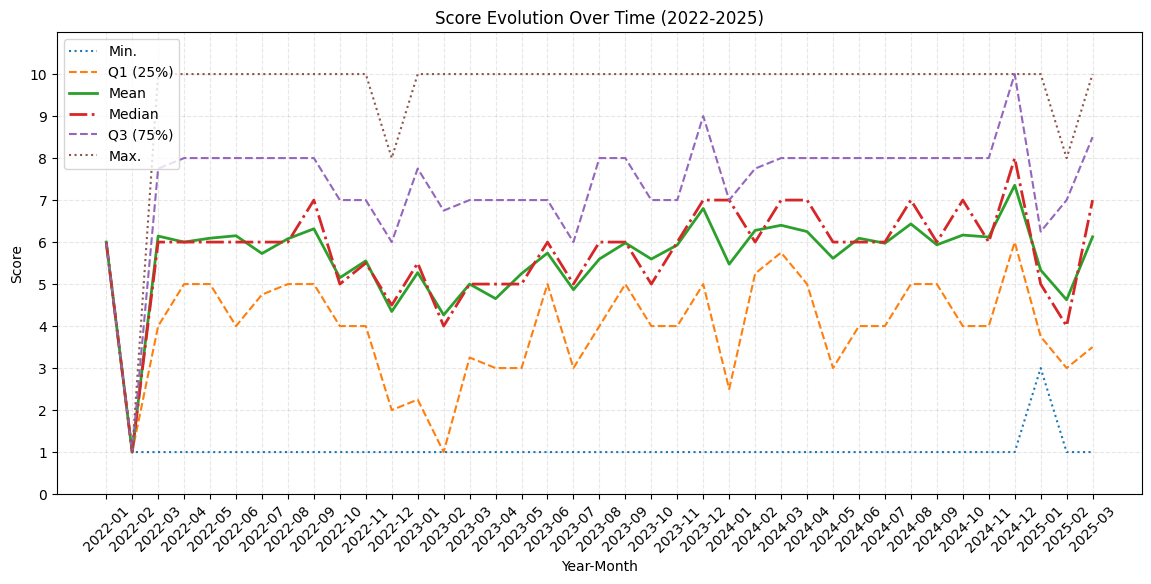

In [25]:
# Calcular estatísticas para cada mês
monthly_stats = df.groupby('year_month')['score'].agg(['min', 'mean', 'median', 'max'])
monthly_stats['q1'] = df.groupby('year_month')['score'].quantile(0.25)
monthly_stats['q3'] = df.groupby('year_month')['score'].quantile(0.75)

# Definir cores da paleta 'tab10'
palette = sns.color_palette("tab10")
colors = {
    "min": palette[0],    # Azul
    "q1": palette[1],     # Laranja
    "mean": palette[2],   # Verde
    "median": palette[3], # Vermelho
    "q3": palette[4],     # Roxo
    "max": palette[5],    # Castanho
}

# Criar gráfico de linhas com a paleta personalizada
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='min', label='Min.', linestyle='dotted', color=colors["min"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='q1', label='Q1 (25%)', linestyle='dashed', color=colors["q1"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='mean', label='Mean', linewidth=2, color=colors["mean"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='median', label='Median', linewidth=2, linestyle='dashdot', color=colors["median"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='q3', label='Q3 (75%)', linestyle='dashed', color=colors["q3"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='max', label='Max.', linestyle='dotted', color=colors["max"])

# Configurações do gráfico
plt.ylim(0, 11)  # Definir limites do eixo Y
plt.yticks(range(0, 11, 1))  # Incrementos unitários no eixo Y
plt.title("Score Evolution Over Time (2022-2025)")
plt.xlabel("Year-Month")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

# Mostrar gráfico

plt.savefig("score_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

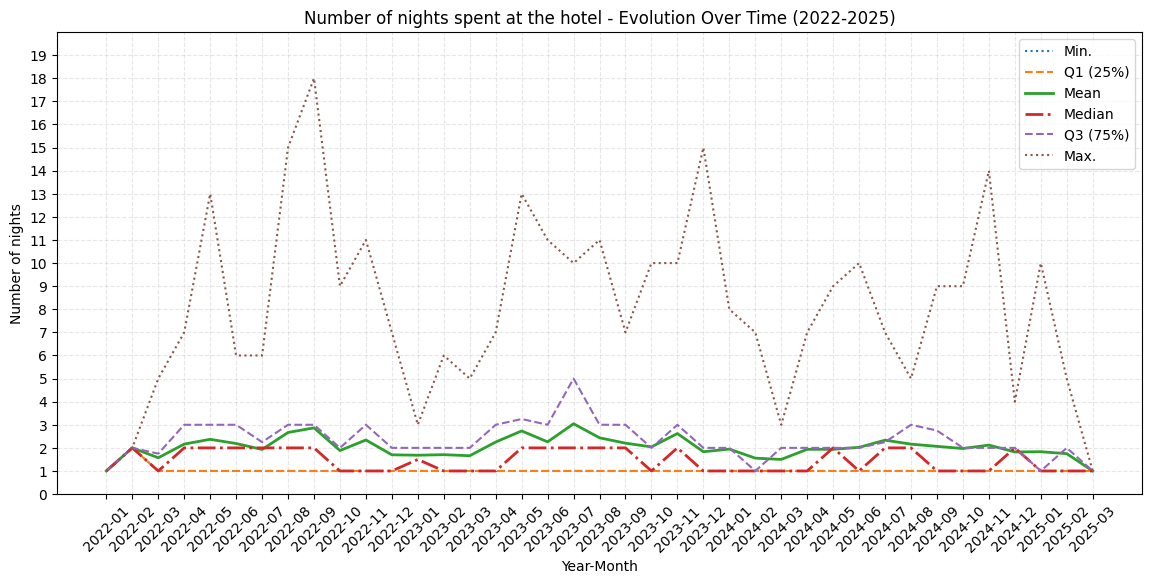

In [26]:
# Calcular estatísticas para cada mês
monthly_stats = df.groupby('year_month')['nr_nights'].agg(['min', 'mean', 'median', 'max'])
monthly_stats['q1'] = df.groupby('year_month')['nr_nights'].quantile(0.25)
monthly_stats['q3'] = df.groupby('year_month')['nr_nights'].quantile(0.75)

# Definir cores da paleta 'tab10'
palette = sns.color_palette("tab10")
colors = {
    "min": palette[0],    # Azul
    "q1": palette[1],     # Laranja
    "mean": palette[2],   # Verde
    "median": palette[3], # Vermelho
    "q3": palette[4],     # Roxo
    "max": palette[5],    # Castanho
}

# Criar gráfico de linhas com a paleta personalizada
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='min', label='Min.', linestyle='dotted', color=colors["min"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='q1', label='Q1 (25%)', linestyle='dashed', color=colors["q1"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='mean', label='Mean', linewidth=2, color=colors["mean"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='median', label='Median', linewidth=2, linestyle='dashdot', color=colors["median"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='q3', label='Q3 (75%)', linestyle='dashed', color=colors["q3"])
sns.lineplot(data=monthly_stats, x=monthly_stats.index, y='max', label='Max.', linestyle='dotted', color=colors["max"])

# Configurações do gráfico
plt.ylim(0, 20)  # Definir limites do eixo Y
plt.yticks(range(0, 20, 1))  # Incrementos unitários no eixo Y
plt.title("Number of nights spent at the hotel - Evolution Over Time (2022-2025)")
plt.xlabel("Year-Month")
plt.ylabel("Number of nights")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)

# Mostrar gráfico

plt.savefig("night_evolution.png", dpi=300, bbox_inches="tight")
plt.show()

### Sentiment Comparison over the years

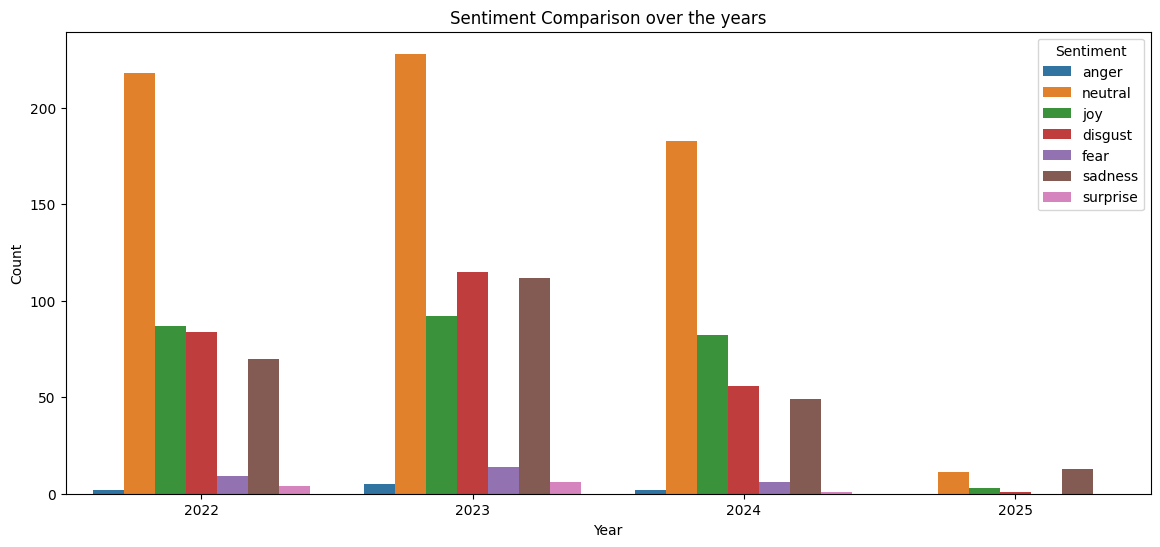

In [28]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="year", hue="emotion", palette="tab10")
plt.title("Sentiment Comparison over the years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Sentiment")
plt.show()

# Sentiment Analysis

### Dominant Sentiment per Room Type

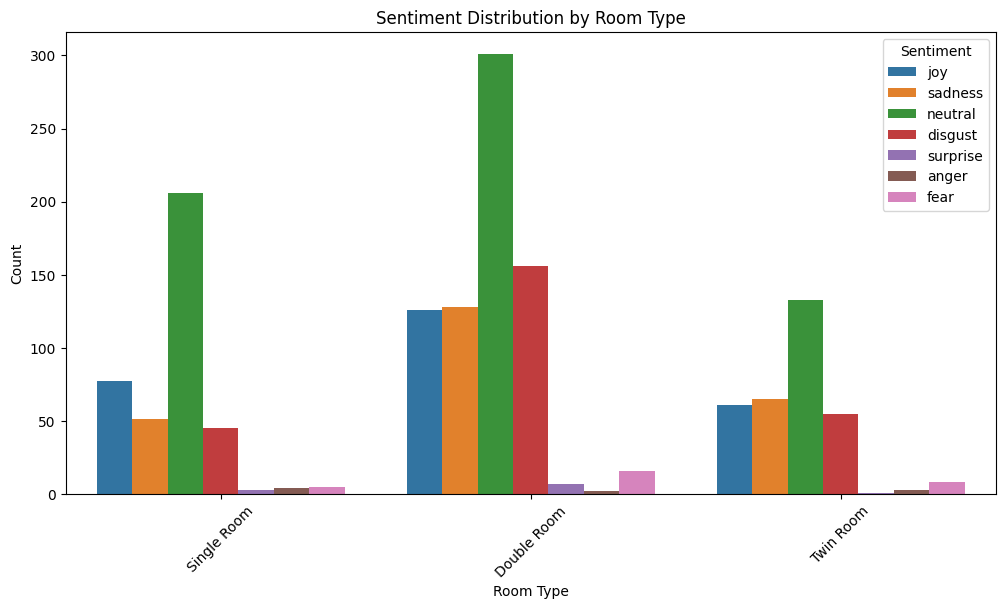

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="room_type", hue="emotion", palette="tab10")
plt.title("Sentiment Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

### Sentiment and Traveler Type

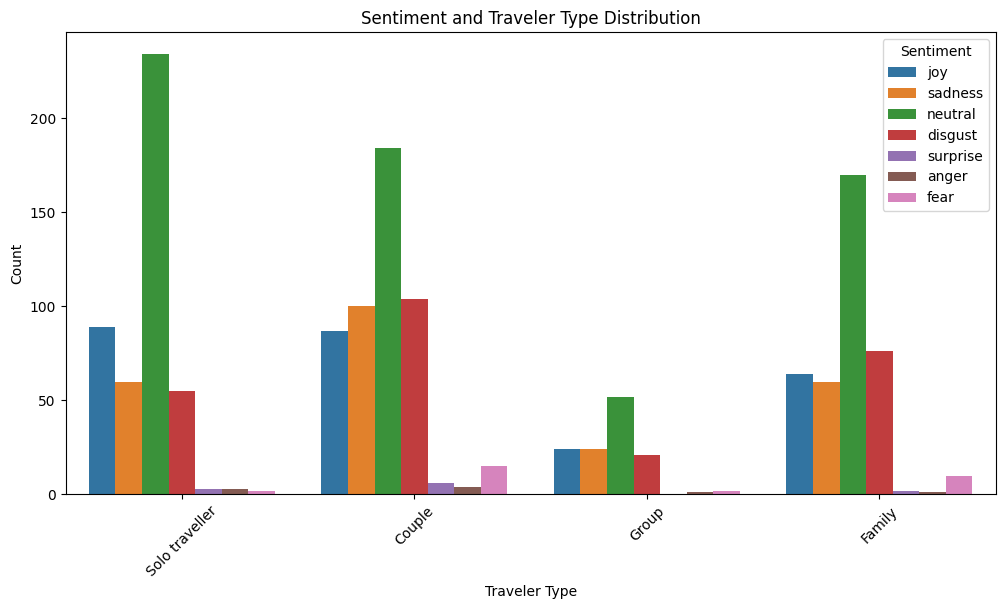

In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="traveler_type", hue="emotion", palette="tab10")
plt.title("Sentiment and Traveler Type Distribution")
plt.xlabel("Traveler Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

### Sentiment and Country of Origin

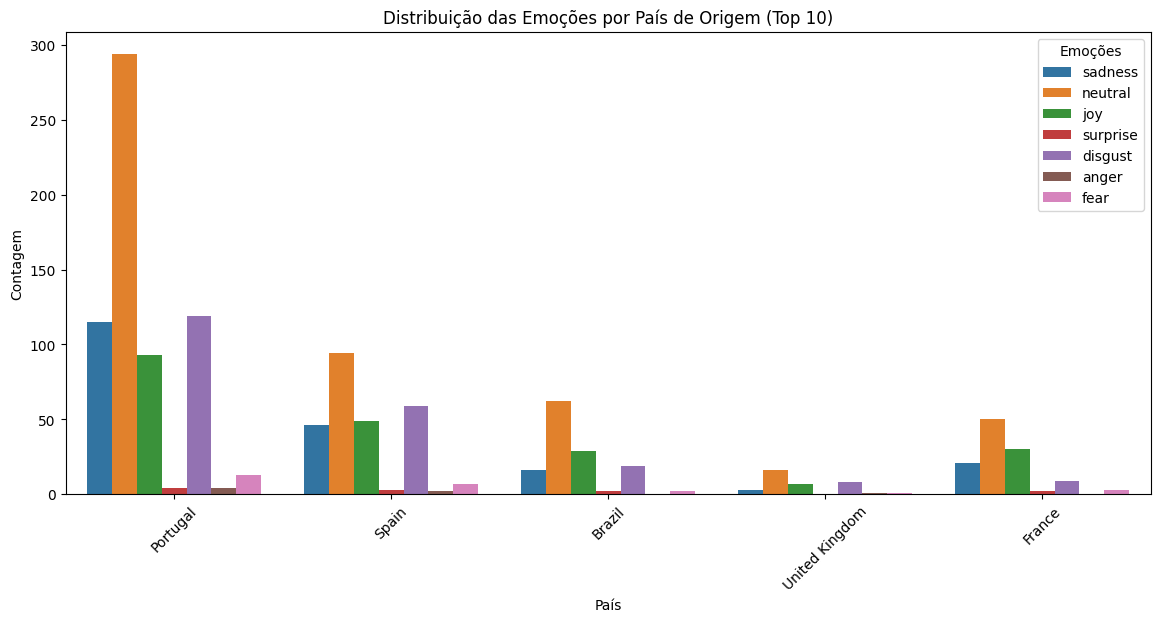

In [35]:
top_countries = df["country"].value_counts().index[:5]  # Pegamos os 10 países mais frequentes
df_filtered = df[df["country"].isin(top_countries)]

plt.figure(figsize=(14, 6))
sns.countplot(data=df_filtered, x="country", hue="emotion", palette="tab10")
plt.title("Distribuição das Emoções por País de Origem (Top 10)")
plt.xlabel("País")
plt.ylabel("Contagem")
plt.xticks(rotation=45)
plt.legend(title="Emoções")
plt.show()

### Sentiment and Review Score

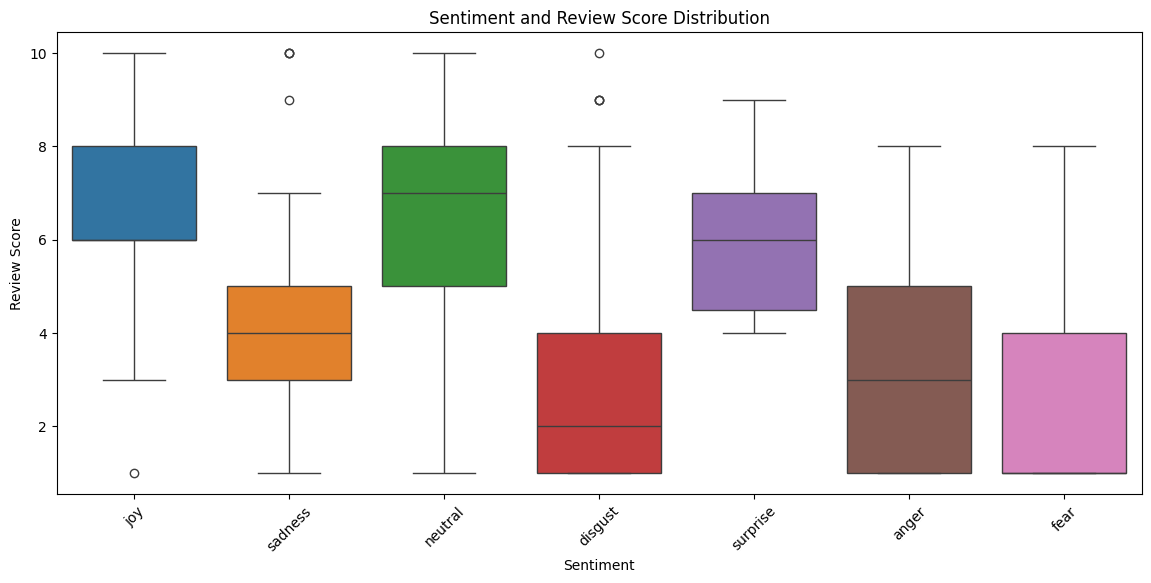

In [37]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="emotion", y="score", hue="emotion", palette="tab10")
plt.title("Sentiment and Review Score Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Review Score")
plt.xticks(rotation=45)
plt.show()

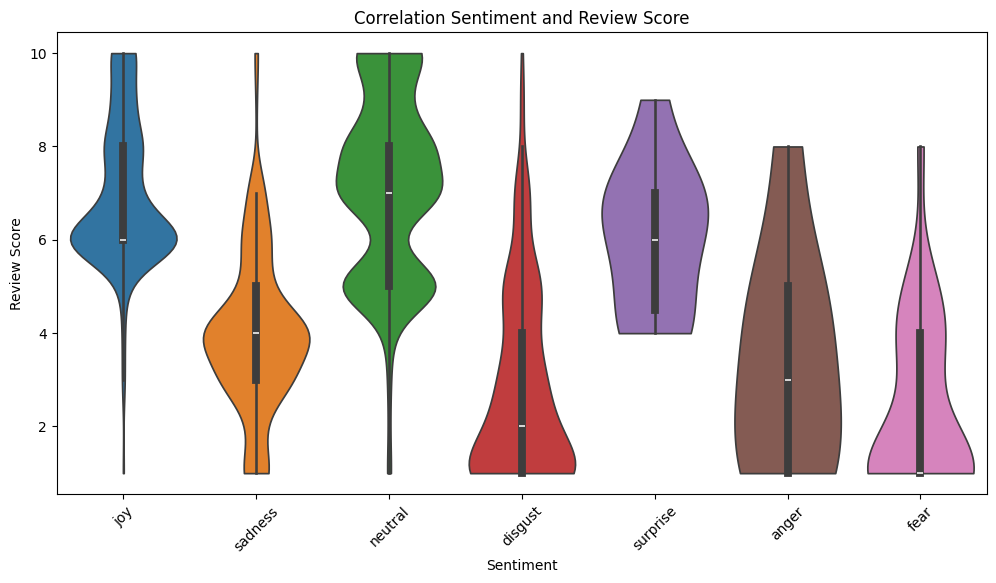

In [38]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x="emotion", y="score",hue="emotion", palette="tab10", cut=0)
plt.title("Correlation Sentiment and Review Score")
plt.xlabel("Sentiment")
plt.ylabel("Review Score")
plt.xticks(rotation=45)
plt.show()

### Length of stay versus Sentiment

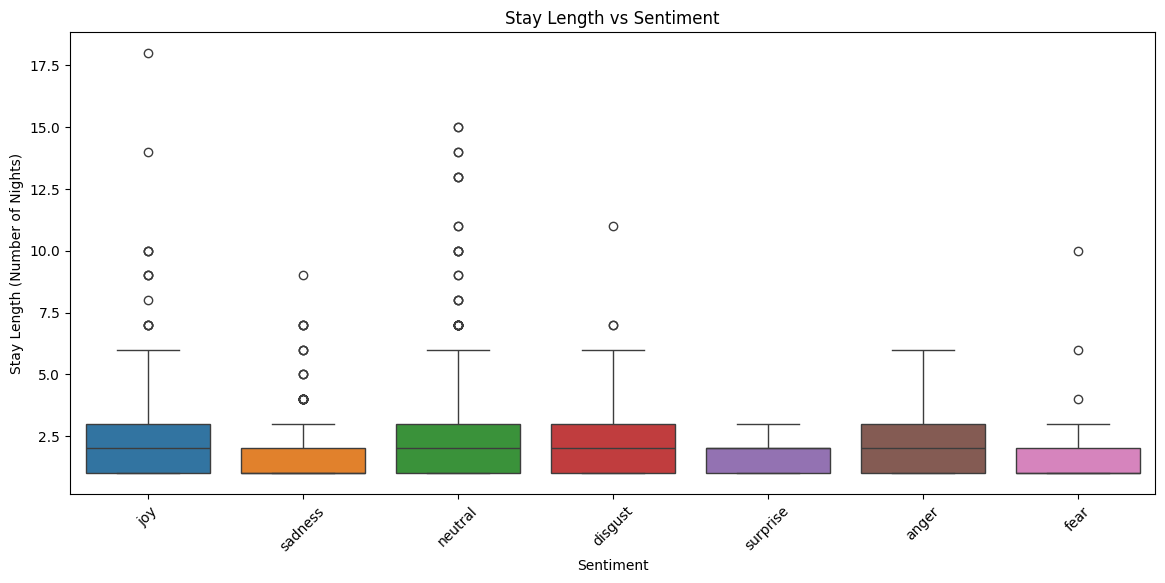

In [46]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="emotion", y="nr_nights", hue="emotion", palette="tab10")
plt.title("Stay Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Stay Length (Number of Nights)")
plt.xticks(rotation=45)
plt.show()

In [49]:
# Saves the dataframes to .csv
df.to_excel("portinari_sentiment.xlsx", index=False, encoding="utf-8")
df.to_csv("portinari_sentiment.csv", index=False, encoding="utf-8")

/opt/anaconda3/lib/python3.12/site-packages/pandas/util/_decorators.py:211: FutureWarning: the 'encoding' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'encoding'
  return func(*args, **kwargs)
